## UMAP Visualization of Training and Prediction Spaces

This notebook uses UMAP to visualize the distribution of the training dataset and the prediction dataset in a shared feature space.

Workflow:
1. Load the training and prediction datasets.
2. Standardize the feature values.
3. Fit UMAP using the prediction dataset.
4. Map the training dataset into the same UMAP space.
5. Plot and export the UMAP coordinates for further visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


In [2]:
import pandas as pd


train = pd.read_csv('data/train_set_all.csv')
pred = pd.read_csv('data/compound_new_MCs_structure.csv')

X_train = train.iloc[:, 1:].values   
X_pred = pred.iloc[:, 1:].values      



In [3]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X_all = np.vstack((X_train, X_pred))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

n_train = X_train.shape[0]
X_train_scaled = X_scaled[:n_train]
X_pred_scaled = X_scaled[n_train:]


In [4]:
import umap.umap_ as umap

umap_model = umap.UMAP(n_neighbors=6, min_dist=0.1, metric='cosine', random_state=21)
X_pred_umap = umap_model.fit_transform(X_pred_scaled)

X_train_umap = umap_model.transform(X_train_scaled)


D:\app\miniconda\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\app\miniconda\envs\py310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
D:\app\miniconda\envs\py310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
D:\app\miniconda\envs\py310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


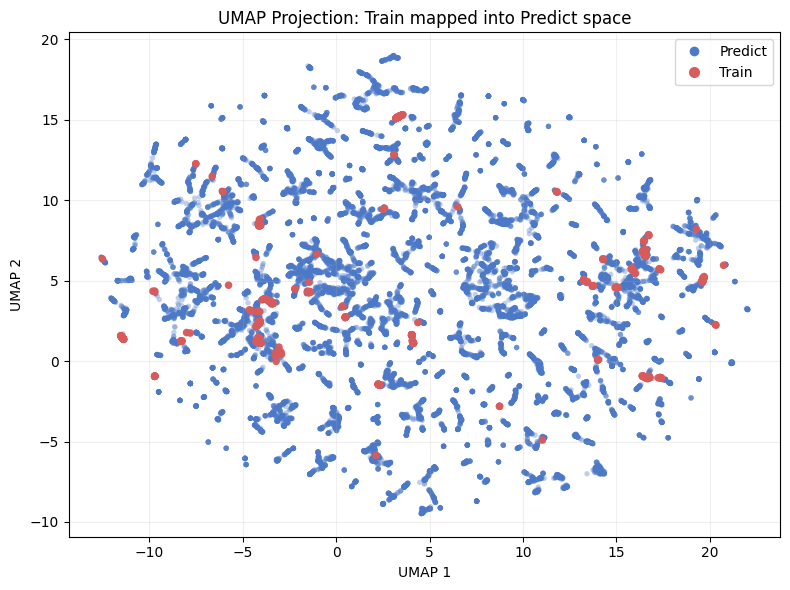

In [5]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

C_TRAIN = "#D95B5B"  
C_PRED  = "#4C79C7" 

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pred_umap[:, 0], X_pred_umap[:, 1],
    c=C_PRED, s=15, marker='o', alpha=0.35,
    edgecolor='none', label='Predict', zorder=1
)

plt.scatter(
    X_train_umap[:, 0], X_train_umap[:, 1],
    c=C_TRAIN, s=30, marker='o', alpha=0.98,
    edgecolor='none', label='Train', zorder=3
)

plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
plt.title("UMAP Projection: Train mapped into Predict space")

handles = [
    Line2D([0],[0], marker='o', linestyle='None', markerfacecolor=C_PRED,  markeredgecolor='none', label='Predict', markersize=7),
    Line2D([0],[0], marker='o', linestyle='None', markerfacecolor=C_TRAIN, markeredgecolor='none', label='Train',   markersize=8),
]
plt.legend(handles=handles, loc="upper right", frameon=True)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [6]:
# Export UMAP coordinates for external plotting
import pandas as pd
import numpy as np

def get_ids(df):
    col0 = df.columns[0]
    return df[col0].astype(str)

train_ids = get_ids(train)
pred_ids  = get_ids(pred)

df_train_out = pd.DataFrame({
    "id":    train_ids.values,
    "UMAP1": X_train_umap[:, 0],
    "UMAP2": X_train_umap[:, 1],
    "set":   "Train",
})

df_pred_out = pd.DataFrame({
    "id":    pred_ids.values,
    "UMAP1": X_pred_umap[:, 0],
    "UMAP2": X_pred_umap[:, 1],
    "set":   "Predict",
})


df_train_out.to_csv("results/umap_coords_train_1.csv", index=False, float_format="%.6f")
df_pred_out.to_csv("results/umap_coords_predict_1.csv", index=False, float_format="%.6f")


df_all = pd.concat([df_train_out, df_pred_out], axis=0, ignore_index=True)
df_all.to_csv("results/umap_coords_all_1.csv", index=False, float_format="%.6f")

print("Saved")


Saved
